In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from tqdm.notebook import tqdm

In [2]:
CLEAN_ROOT = Path('../../data/cmhc-rental-clean')
REF_ROOT   = Path('../../data/reference')
REF_ROOT.mkdir(parents=True, exist_ok=True)

# ── CPI, all-items, 2002=100 (Statistics Canada) ─────────────────────────
CPI_YEARS  = list(range(1990, 2026))
CPI_VALUES = [
    78.7,  82.4,  83.2,  84.7,  84.7,  86.8,  88.2,  89.8,  90.6,  92.4,
    95.1,  98.0, 100.0, 102.7, 104.6, 106.9, 108.8, 110.8, 113.3, 113.7,
   116.5, 120.1, 121.8, 123.0, 125.9, 127.4, 129.7, 131.9, 135.0, 137.5,
   138.4, 143.2, 152.9, 158.7, 162.5, 165.6,
]

# ── Ontario rent-control guideline (annual max % increase) ───────────────
# No entry for 1990 — that is the base year (no prior-year to compound from).
RENT_CONTROL = {
    1991: 5.4, 1992: 6.0, 1993: 4.9, 1994: 3.2, 1995: 2.9,
    1996: 2.8, 1997: 2.8, 1998: 3.0, 1999: 3.0, 2000: 2.6,
    2001: 2.9, 2002: 3.9, 2003: 2.9, 2004: 2.9, 2005: 1.5,
    2006: 2.1, 2007: 2.6, 2008: 1.4, 2009: 1.8, 2010: 2.1,
    2011: 0.7, 2012: 3.1, 2013: 2.5, 2014: 0.8, 2015: 1.6,
    2016: 2.0, 2017: 1.5, 2018: 1.8, 2019: 1.8, 2020: 2.2,
    2021: 0.0, 2022: 1.2, 2023: 2.5, 2024: 2.5, 2025: 2.5,
}

# ── Ontario population, Q1 estimates (Statistics Canada) ─────────────────
POP_Q1 = {
    1990: 10_189_985, 1991: 10_355_101, 1992: 10_488_022, 1993: 10_629_994,
    1994: 10_744_762, 1995: 10_875_308, 1996: 11_009_307, 1997: 11_146_270,
    1998: 11_292_059, 1999: 11_419_589, 2000: 11_576_994, 2001: 11_771_945,
    2002: 11_979_906, 2003: 12_155_691, 2004: 12_303_516, 2005: 12_444_755,
    2006: 12_587_149, 2007: 12_703_327, 2008: 12_814_686, 2009: 12_932_742,
    2010: 13_059_426, 2011: 13_199_081, 2012: 13_325_337, 2013: 13_446_276,
    2014: 13_563_311, 2015: 13_657_423, 2016: 13_774_364, 2017: 13_975_516,
    2018: 14_199_811, 2019: 14_449_986, 2020: 14_718_155, 2021: 14_761_811,
    2022: 14_947_417, 2023: 15_305_369, 2024: 15_823_956, 2025: 16_191_372,
}

# ── Analysis periods (seven-year chunks) ─────────────────────────────────
PERIODS = [
    (1990, 1997),
    (1997, 2004),
    (2004, 2011),
    (2011, 2018),
    (2018, 2025),
]

BASE_YEAR  = 1990
INDEX_BASE = 500

# ── Chart style (reference palette) ──────────────────────────────────────
# Categorical slots in fixed CVD-safe order:
C1 = '#2a78d6'  # blue   — rent
C2 = '#1baf7a'  # aqua   — CPI
C3 = '#eda100'  # yellow — rent control
C4 = '#008300'  # green  — population
# C5 reserved for income when data is available

SURFACE  = '#fcfcfb'
INK      = '#0b0b0b'
INK2     = '#52514e'
MUTED    = '#898781'
GRID_CLR = '#e1e0d9'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.edgecolor':    GRID_CLR,
    'axes.labelcolor':   INK2,
    'xtick.color':       INK2,
    'ytick.color':       INK2,
    'grid.color':        GRID_CLR,
    'grid.linewidth':    0.5,
    'figure.facecolor':  SURFACE,
    'axes.facecolor':    SURFACE,
})

## Section 1 — Reference Data

Persist CPI, rent-control guideline, and Ontario population series to
`data/reference/` so other notebooks can load them without re-entering raw values.
Population uses Q1 estimates; CPI is annual all-items; rent control is the Ontario
annual guideline maximum.

In [3]:
pd.DataFrame({'Year': CPI_YEARS, 'CPI': CPI_VALUES}).to_csv(
    REF_ROOT / 'cpi_canada.csv', index=False)

pd.DataFrame(sorted(RENT_CONTROL.items()), columns=['Year', 'Guideline_Pct']).to_csv(
    REF_ROOT / 'rent_control_ontario.csv', index=False)

pd.DataFrame(sorted(POP_Q1.items()), columns=['Year', 'Population']).to_csv(
    REF_ROOT / 'population_ontario_q1.csv', index=False)

for f in sorted(REF_ROOT.glob('*.csv')):
    print(f.name)

cpi_canada.csv
population_ontario_q1.csv
rent_control_ontario.csv


## Section 2 — Rent vs. Benchmarks (Indexed to 500, base 1990)

Rescaling everything to 500 in 1990 lets us compare growth rates directly across
series with very different units (dollars, index points, people).

**Rent control** is compounded annually from 1990 using the guideline rate — it
shows what rent *would* be today if it had risen exactly at the allowed maximum
every year since 1990.  Note that rent control only applies to units built before
November 2018, and vacant-unit turnover can reset rents to market.

*Slot C5 (income) is reserved — add when data is available.*

In [4]:
ontario = pd.read_csv(
    CLEAN_ROOT / 'can-pr-primary/primary-summary/ontario.csv'
).set_index('Year')

# Rent: direct ratio to base year
rent_idx = INDEX_BASE * ontario['Average Rent'] / ontario.loc[BASE_YEAR, 'Average Rent']

# CPI: direct ratio to base year
cpi_s    = pd.Series(CPI_VALUES, index=CPI_YEARS)
cpi_idx  = INDEX_BASE * cpi_s / cpi_s[BASE_YEAR]

# Rent control: cumulative compound from 1990
rc_idx = pd.Series(index=range(BASE_YEAR, 2026), dtype=float)
rc_idx[BASE_YEAR] = INDEX_BASE
for yr in range(BASE_YEAR + 1, 2026):
    rc_idx[yr] = rc_idx[yr - 1] * (1 + RENT_CONTROL.get(yr, 0.0) / 100)

# Population: direct ratio to base year
pop_s   = pd.Series(POP_Q1).sort_index()
pop_idx = INDEX_BASE * pop_s / pop_s[BASE_YEAR]

benchmark = pd.DataFrame({
    'Rent (Ontario)':  rent_idx,
    'CPI':             cpi_idx,
    'Rent Control':    rc_idx,
    'Population (ON)': pop_idx,
}).loc[1990:2025]

benchmark.tail(3)

,Rent (Ontario),CPI,Rent Control,Population (ON)
2023,1396.701389,1008.259212,1125.617036,751.000566
2024,1446.180556,1032.401525,1153.757461,776.446482
2025,1501.736111,1052.096569,1182.601398,794.474771


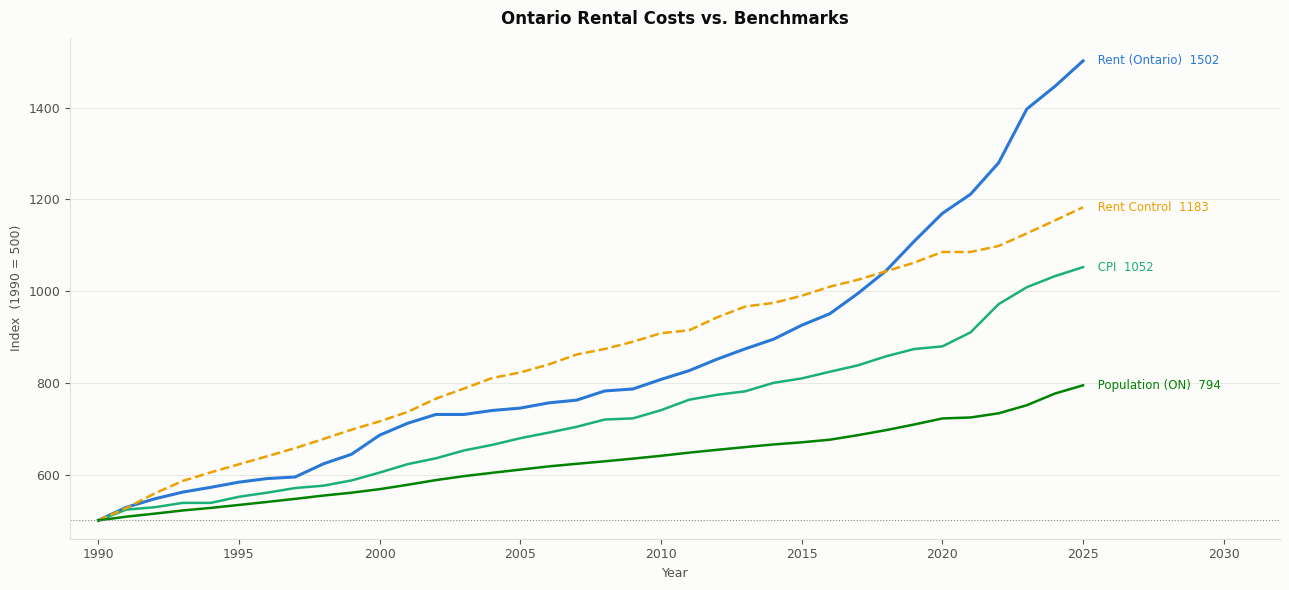

In [5]:
SERIES_STYLE = {
    'Rent (Ontario)':  dict(color=C1, linestyle='solid',  linewidth=2.2),
    'CPI':             dict(color=C2, linestyle='solid',  linewidth=1.8),
    'Rent Control':    dict(color=C3, linestyle='dashed', linewidth=1.8),
    'Population (ON)': dict(color=C4, linestyle='solid',  linewidth=1.8),
}

fig, ax = plt.subplots(figsize=(13, 6))

for label, style in SERIES_STYLE.items():
    ax.plot(benchmark.index, benchmark[label], **style, label=label)

# Direct labels at 2025 — avoids a legend box
for label, style in SERIES_STYLE.items():
    val = benchmark.loc[2025, label]
    ax.text(2025.4, val, f' {label}  {val:.0f}',
            color=style['color'], va='center', fontsize=8.5)

ax.axhline(INDEX_BASE, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlim(1989, 2032)
ax.set_ylim(bottom=460)
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('Index  (1990 = 500)', fontsize=9)
ax.set_title('Ontario Rental Costs vs. Benchmarks', fontsize=12,
             fontweight='bold', color=INK, pad=10)
ax.grid(axis='y')
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## Section 3A — Supply and Rent: Ontario Level (Year-over-Year)

Each dot is one year (1991–2025). x = year-over-year % change in primary rental
units; y = year-over-year % change in average rent.  Dots shade from light to dark
as years approach the present.  If the supply-suppresses-rent thesis held, we would
expect a negative slope.

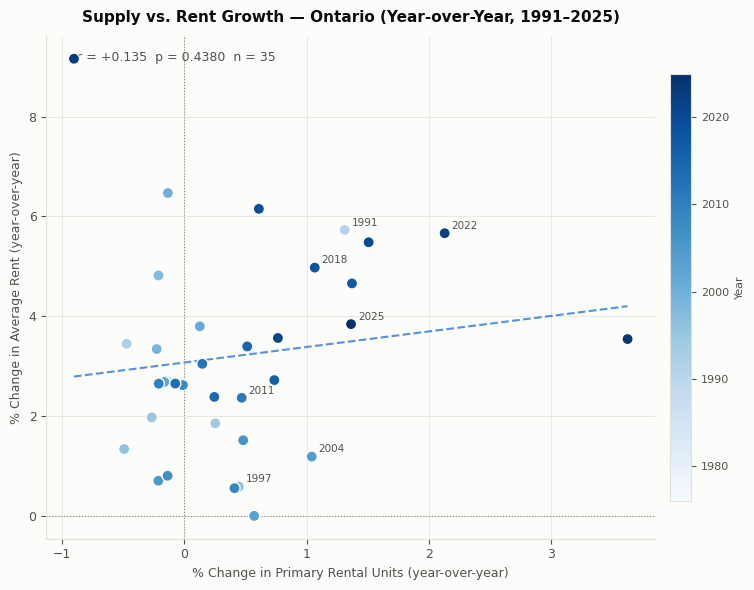

In [6]:
# Year-over-year % change in units and average rent
yoy = pd.DataFrame({
    'pct_rent':  ontario['Average Rent'].pct_change() * 100,
    'pct_units': ontario['Units'].pct_change() * 100,
}).dropna()  # drops 1990 (no prior year)

slope, intercept, r, p, _ = stats.linregress(yoy['pct_units'], yoy['pct_rent'])

fig, ax = plt.subplots(figsize=(8, 6))

# vmin offset so the earliest years are still a visible blue (not near-white)
sc = ax.scatter(yoy['pct_units'], yoy['pct_rent'],
                c=yoy.index, cmap='Blues',
                vmin=yoy.index.min() - 15, vmax=yoy.index.max(),
                s=65, zorder=5, edgecolors=SURFACE, linewidths=1.0)

# Regression line
xfit = np.linspace(yoy['pct_units'].min(), yoy['pct_units'].max(), 100)
ax.plot(xfit, slope * xfit + intercept,
        color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

# Year labels for notable points
for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy.index:
        ax.annotate(str(yr),
                    (yoy.loc[yr, 'pct_units'], yoy.loc[yr, 'pct_rent']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=INK2)

p_str = f'p = {p:.4f}' if p >= 0.0001 else 'p < 0.0001'
ax.text(0.05, 0.97, f'r = {r:+.3f}  {p_str}  n = {len(yoy)}',
        transform=ax.transAxes, va='top', fontsize=9, color=INK2)

cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Year', fontsize=8, color=INK2)
cbar.ax.tick_params(labelsize=8, colors=INK2)

ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('% Change in Primary Rental Units (year-over-year)', fontsize=9)
ax.set_ylabel('% Change in Average Rent (year-over-year)', fontsize=9)
ax.set_title('Supply vs. Rent Growth — Ontario (Year-over-Year, 1991–2025)',
             fontsize=11, fontweight='bold', color=INK, pad=10)
ax.grid()
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()


## Section 3B — Demand-Adjusted Supply vs. Rent (Population-Normalised)

Same year-over-year scatter as 3A, but the x-axis now controls for population growth:
x = change in primary rental units *per 1,000 Ontario residents* that year.

This removes the confound that supply additions look bigger in absolute terms as the
province grows.  A flat or positive slope here still contradicts the simple
supply-suppresses-rent thesis even after accounting for demand growth.

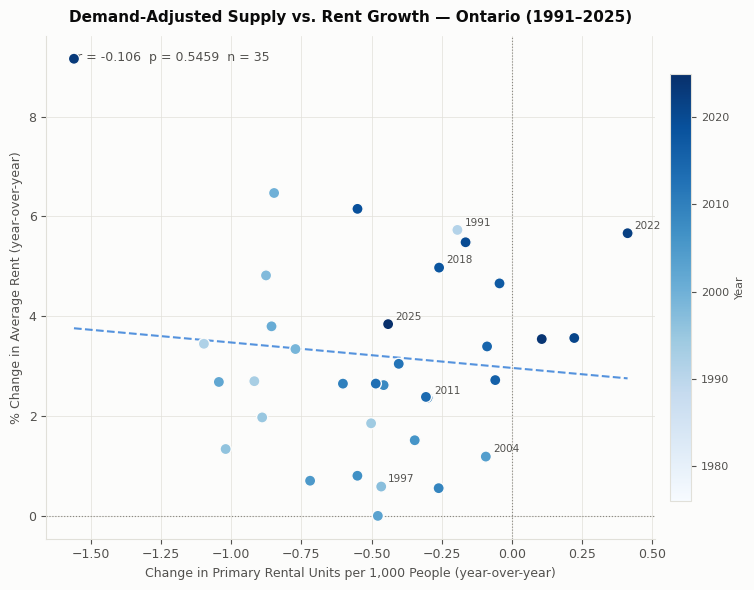

In [7]:
pop_s_b = pd.Series(POP_Q1).sort_index()

# Supply density: rental units per 1,000 Ontario residents
units_per_1k = ontario['Units'] / (pop_s_b / 1_000)

yoy_b = pd.DataFrame({
    'pct_rent':           ontario['Average Rent'].pct_change() * 100,
    'delta_units_per_1k': units_per_1k.diff(),   # absolute year-over-year change in density
}).dropna()

slope_b, intercept_b, r_b, p_b, _ = stats.linregress(
    yoy_b['delta_units_per_1k'], yoy_b['pct_rent'])

fig, ax = plt.subplots(figsize=(8, 6))

sc_b = ax.scatter(yoy_b['delta_units_per_1k'], yoy_b['pct_rent'],
                  c=yoy_b.index, cmap='Blues',
                  vmin=yoy_b.index.min() - 15, vmax=yoy_b.index.max(),
                  s=65, zorder=5, edgecolors=SURFACE, linewidths=1.0)

xfit_b = np.linspace(yoy_b['delta_units_per_1k'].min(),
                     yoy_b['delta_units_per_1k'].max(), 100)
ax.plot(xfit_b, slope_b * xfit_b + intercept_b,
        color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy_b.index:
        ax.annotate(str(yr),
                    (yoy_b.loc[yr, 'delta_units_per_1k'], yoy_b.loc[yr, 'pct_rent']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=INK2)

p_str_b = f'p = {p_b:.4f}' if p_b >= 0.0001 else 'p < 0.0001'
ax.text(0.05, 0.97, f'r = {r_b:+.3f}  {p_str_b}  n = {len(yoy_b)}',
        transform=ax.transAxes, va='top', fontsize=9, color=INK2)

cbar_b = fig.colorbar(sc_b, ax=ax, pad=0.02, shrink=0.85)
cbar_b.set_label('Year', fontsize=8, color=INK2)
cbar_b.ax.tick_params(labelsize=8, colors=INK2)

ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('Change in Primary Rental Units per 1,000 People (year-over-year)', fontsize=9)
ax.set_ylabel('% Change in Average Rent (year-over-year)', fontsize=9)
ax.set_title('Demand-Adjusted Supply vs. Rent Growth — Ontario (1991–2025)',
             fontsize=11, fontweight='bold', color=INK, pad=10)
ax.grid()
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## Section 3C — Vacancy Rate as a Demand Signal

**Left:** vacancy rate (x) vs. year-over-year rent increase (y) — a vacancy rate
below ~3 % is generally considered a landlord's market.  We expect higher vacancy
to correlate with lower rent growth.

**Right:** same supply-vs-rent scatter as 3A, but dot size now encodes the vacancy
rate that year (larger dot = higher vacancy, more slack in the market).  This lets
us see whether years with the same supply change had different rent outcomes
depending on underlying market tightness.

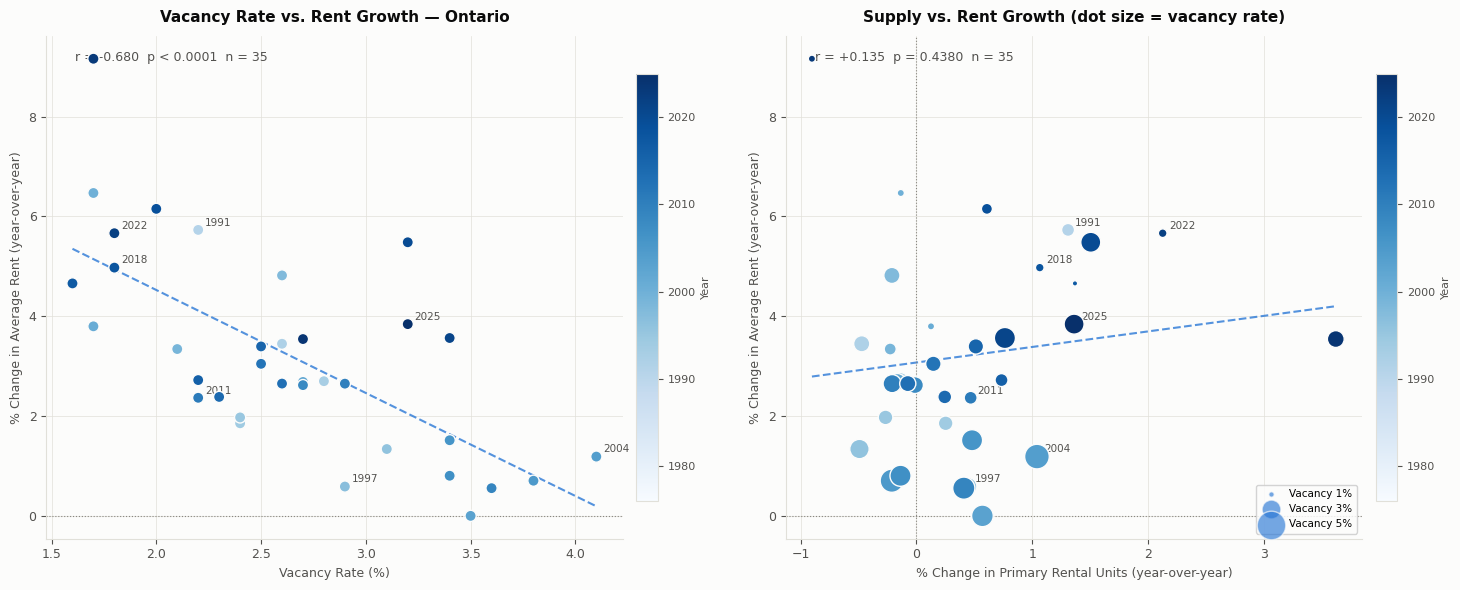

In [8]:
yoy_c = pd.DataFrame({
    'pct_rent':     ontario['Average Rent'].pct_change() * 100,
    'vacancy_rate': ontario['Vacancy Rate'],
    'pct_units':    ontario['Units'].pct_change() * 100,
}).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── Plot 1: Vacancy Rate vs Rent Change ──────────────────────────────────────
slope_c1, intercept_c1, r_c1, p_c1, _ = stats.linregress(
    yoy_c['vacancy_rate'], yoy_c['pct_rent'])

sc1 = ax1.scatter(yoy_c['vacancy_rate'], yoy_c['pct_rent'],
                  c=yoy_c.index, cmap='Blues',
                  vmin=yoy_c.index.min() - 15, vmax=yoy_c.index.max(),
                  s=65, zorder=5, edgecolors=SURFACE, linewidths=1.0)

xfit_c1 = np.linspace(yoy_c['vacancy_rate'].min(), yoy_c['vacancy_rate'].max(), 100)
ax1.plot(xfit_c1, slope_c1 * xfit_c1 + intercept_c1,
         color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy_c.index:
        ax1.annotate(str(yr),
                     (yoy_c.loc[yr, 'vacancy_rate'], yoy_c.loc[yr, 'pct_rent']),
                     xytext=(5, 3), textcoords='offset points',
                     fontsize=7.5, color=INK2)

p_str_c1 = f'p = {p_c1:.4f}' if p_c1 >= 0.0001 else 'p < 0.0001'
ax1.text(0.05, 0.97, f'r = {r_c1:+.3f}  {p_str_c1}  n = {len(yoy_c)}',
         transform=ax1.transAxes, va='top', fontsize=9, color=INK2)

cbar1 = fig.colorbar(sc1, ax=ax1, pad=0.02, shrink=0.85)
cbar1.set_label('Year', fontsize=8, color=INK2)
cbar1.ax.tick_params(labelsize=8, colors=INK2)

ax1.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax1.set_xlabel('Vacancy Rate (%)', fontsize=9)
ax1.set_ylabel('% Change in Average Rent (year-over-year)', fontsize=9)
ax1.set_title('Vacancy Rate vs. Rent Growth — Ontario',
              fontsize=11, fontweight='bold', color=INK, pad=10)
ax1.grid()
ax1.tick_params(labelsize=9)

# ── Plot 2: Supply change vs Rent change, dot size = vacancy rate ────────────
vac_min, vac_max = yoy_c['vacancy_rate'].min(), yoy_c['vacancy_rate'].max()
sizes_c2 = 15 + ((yoy_c['vacancy_rate'] - vac_min) / (vac_max - vac_min)) * 300

slope_c2, intercept_c2, r_c2, p_c2, _ = stats.linregress(
    yoy_c['pct_units'], yoy_c['pct_rent'])

sc2 = ax2.scatter(yoy_c['pct_units'], yoy_c['pct_rent'],
                  c=yoy_c.index, cmap='Blues',
                  vmin=yoy_c.index.min() - 15, vmax=yoy_c.index.max(),
                  s=sizes_c2, zorder=5, edgecolors=SURFACE, linewidths=1.0)

xfit_c2 = np.linspace(yoy_c['pct_units'].min(), yoy_c['pct_units'].max(), 100)
ax2.plot(xfit_c2, slope_c2 * xfit_c2 + intercept_c2,
         color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy_c.index:
        ax2.annotate(str(yr),
                     (yoy_c.loc[yr, 'pct_units'], yoy_c.loc[yr, 'pct_rent']),
                     xytext=(5, 3), textcoords='offset points',
                     fontsize=7.5, color=INK2)

p_str_c2 = f'p = {p_c2:.4f}' if p_c2 >= 0.0001 else 'p < 0.0001'
ax2.text(0.05, 0.97, f'r = {r_c2:+.3f}  {p_str_c2}  n = {len(yoy_c)}',
         transform=ax2.transAxes, va='top', fontsize=9, color=INK2)

# Vacancy size legend
for vac_lvl in [1, 3, 5]:
    s = 15 + ((vac_lvl - vac_min) / (vac_max - vac_min)) * 300
    ax2.scatter([], [], s=max(s, 15), color=C1, alpha=0.65,
                edgecolors=SURFACE, linewidths=1.0, label=f'Vacancy {vac_lvl}%')
ax2.legend(loc='lower right', fontsize=7.5, framealpha=0.85)

cbar2 = fig.colorbar(sc2, ax=ax2, pad=0.02, shrink=0.85)
cbar2.set_label('Year', fontsize=8, color=INK2)
cbar2.ax.tick_params(labelsize=8, colors=INK2)

ax2.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax2.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax2.set_xlabel('% Change in Primary Rental Units (year-over-year)', fontsize=9)
ax2.set_ylabel('% Change in Average Rent (year-over-year)', fontsize=9)
ax2.set_title('Supply vs. Rent Growth (dot size = vacancy rate)',
              fontsize=11, fontweight='bold', color=INK, pad=10)
ax2.grid()
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## Section 3D — New Supply vs. Above-Guideline Rent Gap

Each dot is one year (1991–2025).  x = year-over-year % change in primary rental units;
y = how much rent actually rose *above* the Ontario guideline maximum that year
(negative = rent grew slower than the guideline).

If new supply put downward pressure on rent inflation we would expect a negative slope
— more supply growth → smaller excess gap.

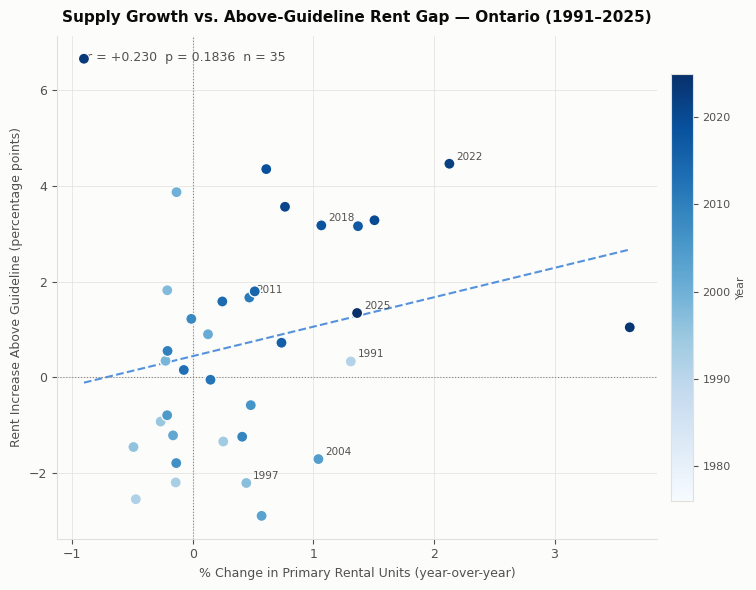

In [9]:
yoy_d = pd.DataFrame({
    'pct_units': ontario['Units'].pct_change() * 100,
    'pct_rent':  ontario['Average Rent'].pct_change() * 100,
}).dropna()

yoy_d['guideline'] = yoy_d.index.map(lambda yr: RENT_CONTROL.get(yr, 0.0))
yoy_d['gap'] = yoy_d['pct_rent'] - yoy_d['guideline']  # pp above guideline

slope_d, intercept_d, r_d, p_d, _ = stats.linregress(yoy_d['pct_units'], yoy_d['gap'])

fig, ax = plt.subplots(figsize=(8, 6))

sc_d = ax.scatter(yoy_d['pct_units'], yoy_d['gap'],
                  c=yoy_d.index, cmap='Blues',
                  vmin=yoy_d.index.min() - 15, vmax=yoy_d.index.max(),
                  s=65, zorder=5, edgecolors=SURFACE, linewidths=1.0)

xfit_d = np.linspace(yoy_d['pct_units'].min(), yoy_d['pct_units'].max(), 100)
ax.plot(xfit_d, slope_d * xfit_d + intercept_d,
        color=C1, linewidth=1.5, linestyle='--', alpha=0.8)

for yr in [1991, 1997, 2004, 2011, 2018, 2022, 2025]:
    if yr in yoy_d.index:
        ax.annotate(str(yr),
                    (yoy_d.loc[yr, 'pct_units'], yoy_d.loc[yr, 'gap']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=INK2)

p_str_d = f'p = {p_d:.4f}' if p_d >= 0.0001 else 'p < 0.0001'
ax.text(0.05, 0.97, f'r = {r_d:+.3f}  {p_str_d}  n = {len(yoy_d)}',
        transform=ax.transAxes, va='top', fontsize=9, color=INK2)

cbar_d = fig.colorbar(sc_d, ax=ax, pad=0.02, shrink=0.85)
cbar_d.set_label('Year', fontsize=8, color=INK2)
cbar_d.ax.tick_params(labelsize=8, colors=INK2)

ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('% Change in Primary Rental Units (year-over-year)', fontsize=9)
ax.set_ylabel('Rent Increase Above Guideline (percentage points)', fontsize=9)
ax.set_title('Supply Growth vs. Above-Guideline Rent Gap — Ontario (1991–2025)',
             fontsize=11, fontweight='bold', color=INK, pad=10)
ax.grid()
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## Section 4 — Supply and Rent: City Level (Small Multiples)

Each panel is one seven-year period; each dot is an Ontario CSD city.  Dot size
scales with the number of primary rental units at the start of the period
(larger city = bigger dot).  Cities without data for both endpoints of a period
are omitted from that panel.

The dashed line is an OLS fit.  If supply suppressed rents we would expect a
negative slope (more units built → smaller rent increase).

In [10]:
CITY_DIR = CLEAN_ROOT / 'on-csd-primary/primary-summary'

city_data = {}
for fp in tqdm(sorted(CITY_DIR.glob('*.csv'))):
    df = pd.read_csv(fp).set_index('Year')
    city_data[fp.stem] = df


def period_city_df(start_yr: int, end_yr: int) -> pd.DataFrame:
    """Return a df with one row per city that has data at both endpoints."""
    rows = []
    for city, df in city_data.items():
        try:
            r0 = df.loc[start_yr, 'Average Rent']
            r1 = df.loc[end_yr,   'Average Rent']
            u0 = df.loc[start_yr, 'Units']
            u1 = df.loc[end_yr,   'Units']
        except KeyError:
            continue
        if any(pd.isna(v) for v in (r0, r1, u0, u1)) or u0 == 0:
            continue
        rows.append({
            'city':        city,
            'pct_rent':    (r1 - r0) / r0  * 100,
            'pct_units':   (u1 - u0) / u0  * 100,
            'units_start': u0,
        })
    return pd.DataFrame(rows)


period_city_dfs = {f'{s}\u2013{e}': period_city_df(s, e) for s, e in PERIODS}

for label, df in period_city_dfs.items():
    print(f'{label}: {len(df)} cities')

  0%|          | 0/34 [00:00<?, ?it/s]

1990–1997: 24 cities
1997–2004: 25 cities
2004–2011: 32 cities
2011–2018: 32 cities
2018–2025: 32 cities


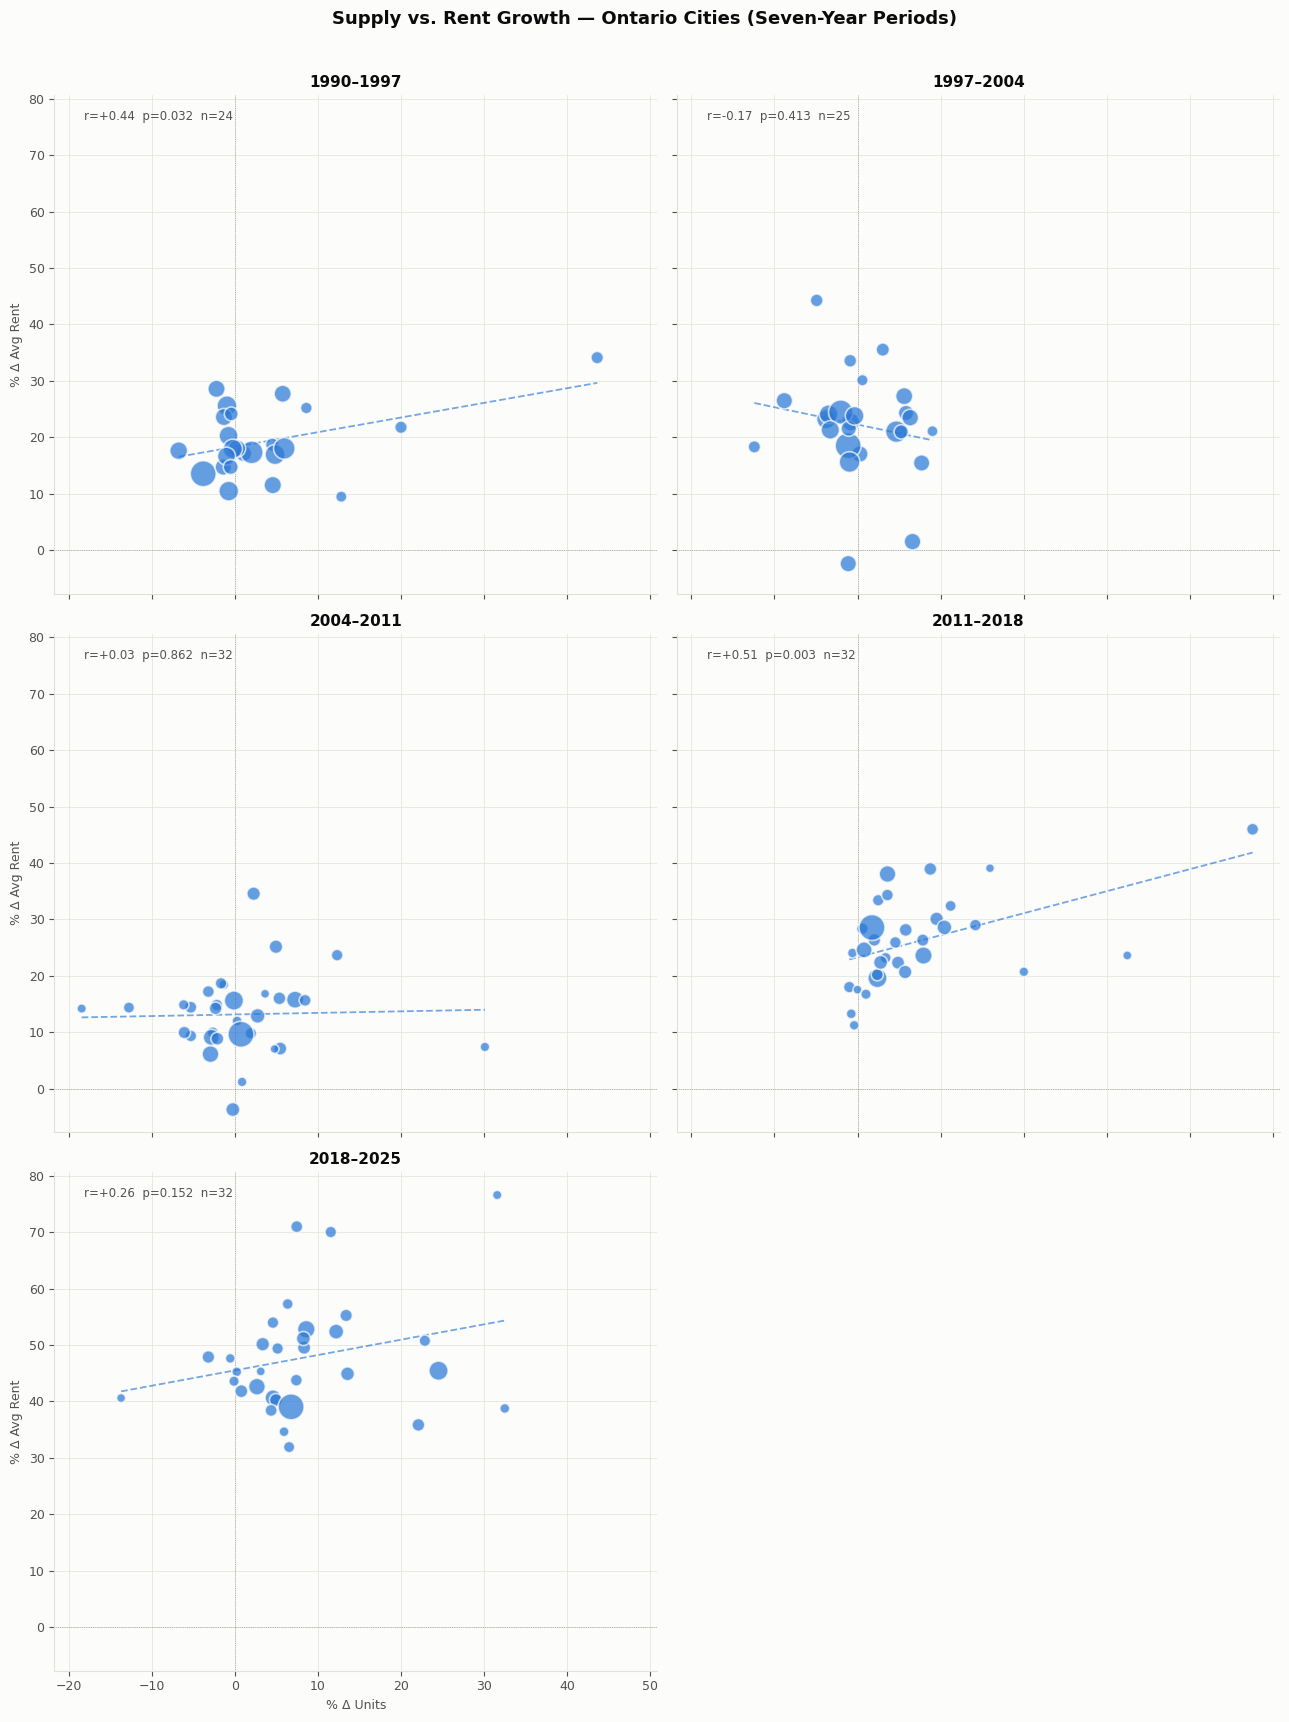

In [11]:
MIN_S, MAX_S = 25, 350

fig, axes = plt.subplots(3, 2, figsize=(13, 17), sharex=True, sharey=True)
axes_flat = axes.flatten()

fig.suptitle('Supply vs. Rent Growth — Ontario Cities (Seven-Year Periods)',
             fontsize=13, fontweight='bold', color=INK, y=1.01)

for i, (ax, (label, df)) in enumerate(zip(axes_flat, period_city_dfs.items())):
    ax.set_title(label, fontsize=11, fontweight='bold', color=INK)

    if df.empty or len(df) < 3:
        ax.text(0.5, 0.5, 'Insufficient data',
                ha='center', va='center', transform=ax.transAxes,
                color=MUTED, fontsize=9)
        continue

    sz = MIN_S + (np.sqrt(df['units_start']) / np.sqrt(df['units_start'].max())) * (MAX_S - MIN_S)

    ax.scatter(df['pct_units'], df['pct_rent'],
               s=sz, color=C1, alpha=0.72,
               edgecolors=SURFACE, linewidths=1.2, zorder=5)

    slope, intercept, r, p, _ = stats.linregress(df['pct_units'], df['pct_rent'])
    xfit = np.linspace(df['pct_units'].min(), df['pct_units'].max(), 100)
    ax.plot(xfit, slope * xfit + intercept,
            color=C1, linewidth=1.3, linestyle='--', alpha=0.65)

    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    ax.text(0.05, 0.97, f'r={r:+.2f}  {p_str}  n={len(df)}',
            transform=ax.transAxes, va='top', fontsize=8.5, color=INK2)

    ax.axhline(0, color=MUTED, linewidth=0.5, linestyle=':')
    ax.axvline(0, color=MUTED, linewidth=0.5, linestyle=':')
    ax.grid()
    ax.tick_params(labelsize=9)

# Shared axis labels on outer edges only
for ax in axes[:, 0]:
    ax.set_ylabel('% Δ Avg Rent', fontsize=9, color=INK2)
for ax in axes[-1, :]:
    ax.set_xlabel('% Δ Units', fontsize=9, color=INK2)

# Hide unused 6th panel
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# Pool all city-period observations for an overall test
pooled = pd.concat(
    [df.assign(period=label) for label, df in period_city_dfs.items()],
    ignore_index=True,
)

r_all, p_all = stats.pearsonr(pooled['pct_units'], pooled['pct_rent'])
print(f'Pooled (all cities x periods)  r = {r_all:+.3f}  p = {p_all:.4f}  n = {len(pooled)}')
print()

# Per-period breakdown
rows = []
for label, df in period_city_dfs.items():
    if len(df) < 3:
        rows.append({'Period': label, 'r': None, 'p': None, 'n': len(df), 'note': 'too few cities'})
        continue
    r, p = stats.pearsonr(df['pct_units'], df['pct_rent'])
    rows.append({'Period': label, 'r': round(r, 3), 'p': round(p, 4), 'n': len(df), 'note': ''})

stats_df = pd.DataFrame(rows).set_index('Period')
stats_df

Pooled (all cities x periods)  r = +0.366  p = 0.0000  n = 145



,r,p,n,note
Period,,,,
1990–1997,0.438,0.0324,24,
1997–2004,-0.171,0.4132,25,
2004–2011,0.032,0.8621,32,
2011–2018,0.511,0.0028,32,
2018–2025,0.259,0.1520,32,
